In [1]:
from schemes import * 
from trajectories import *
from utils import *

## I. Multi-factor approximation

In [2]:
tau, T = 1/106, 1/12
t_grid = np.linspace(0, T, 252+1)

### I.1. Fractional kernel 

In [5]:
H = 0.1 
n_fact_values = np.arange(1, 31)

In [6]:
w_star_values, x_star_values = [], []
for n_fact in n_fact_values : 
    r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T, eps=0.0, r_min=1.0001, r_max=5.0)
    w_star_values.append(w_star); x_star_values.append(x_star)

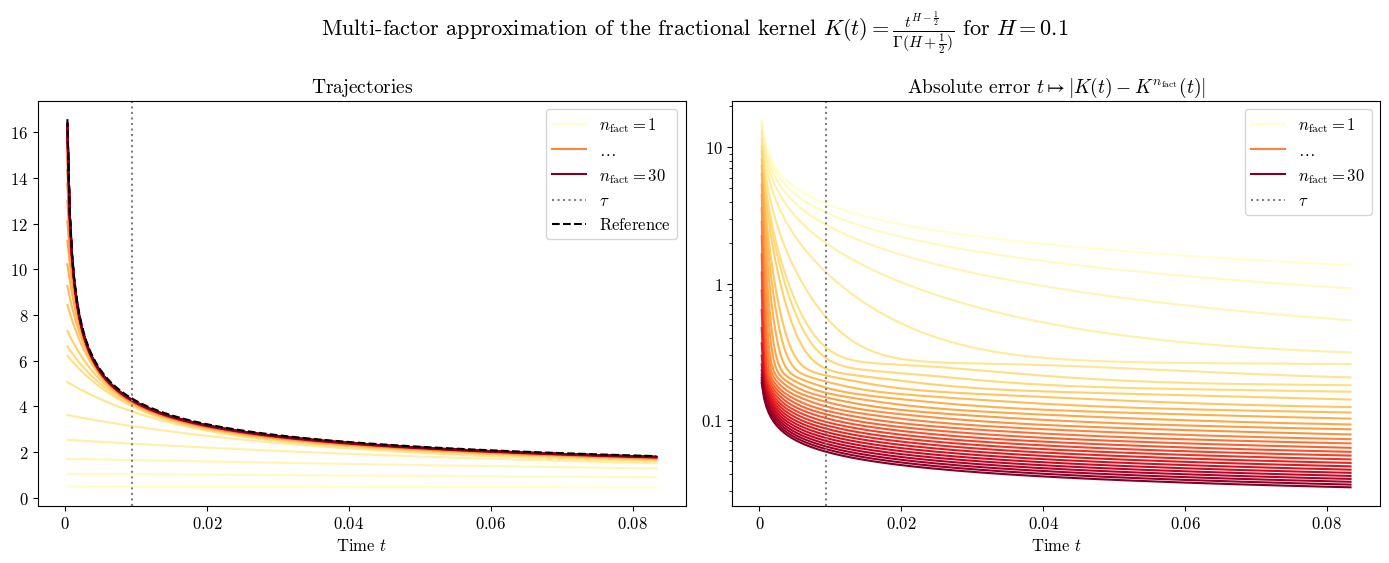

In [215]:
cmap = plt.get_cmap("YlOrRd", len(n_fact_values))
norm = mcolors.Normalize(vmin=n_fact_values.min(), vmax=n_fact_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(1, 2, figsize=(14,5.7))
for i, n_fact in enumerate(n_fact_values) : 
    color = cmap(norm(n_fact))
    if i == 0 or i == len(n_fact_values)-1 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
        ax[1].semilogy(t_grid[1:], np.abs(K_frac(t_grid[1:], H) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
    elif i == len(n_fact_values)//2 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$\ldots$")
        ax[1].semilogy(t_grid[1:], np.abs(K_frac(t_grid[1:], H) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color)
        ax[1].semilogy(t_grid[1:], np.abs(K_frac(t_grid[1:], H) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color)
ax[0].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[1].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[0].plot(t_grid[1:], K_frac(t_grid[1:], H), color="black", linestyle="--", label=r"$\text{Reference}$")

for i in range(2) : 
    ax[i].legend(fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\text{Trajectories}$", fontsize=14)
ax[1].set_title(r"$\text{Absolute error }t\mapsto|K(t)-K^{n_\text{fact}}(t)|$", fontsize=14)
fig.suptitle(r"$\text{Multi-factor approximation of the fractional kernel }K(t) = \frac{t^{H-\frac{1}{2}}}{\Gamma(H+\frac{1}{2})} \text{ for } H=0.1$", fontsize=16)
plt.tight_layout()
plt.show()

### I.2. Shifted fractional kernel 

In [238]:
H, eps = -0.3, 1/52
n_fact_values = np.arange(1, 21)

In [239]:
w_star_values, x_star_values = [], []
for n_fact in n_fact_values : 
    r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T, eps=eps, r_min=1.0001, r_max=4.0)
    w_star_values.append(w_star); x_star_values.append(x_star)

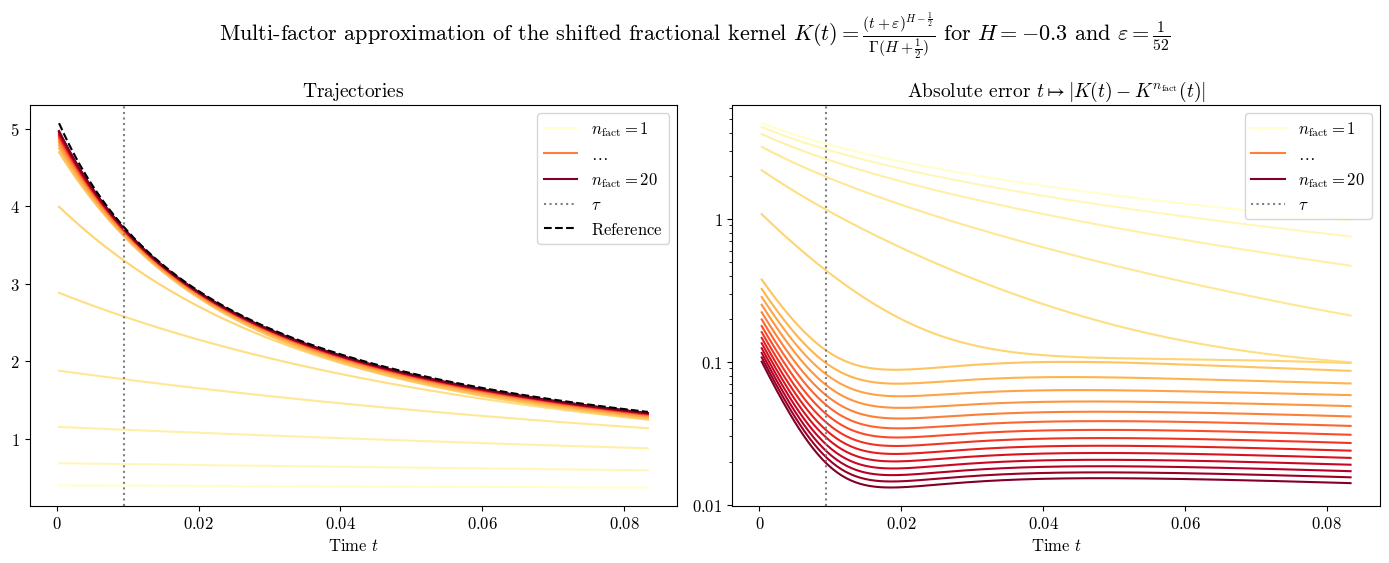

In [245]:
cmap = plt.get_cmap("YlOrRd", len(n_fact_values))
norm = mcolors.Normalize(vmin=n_fact_values.min(), vmax=n_fact_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(1, 2, figsize=(14,5.7))
for i, n_fact in enumerate(n_fact_values) : 
    color = cmap(norm(n_fact))
    if i == 0 or i == len(n_fact_values)-1 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
    elif i == len(n_fact_values)//2 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$\ldots$")
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color)
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color)
ax[0].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[1].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[0].plot(t_grid[1:], K_shift(t_grid[1:], H, eps), color="black", linestyle="--", label=r"$\text{Reference}$")

for i in range(2) : 
    ax[i].legend(fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\text{Trajectories}$", fontsize=14)
ax[1].set_title(r"$\text{Absolute error }t\mapsto|K(t)-K^{n_\text{fact}}(t)|$", fontsize=14)
fig.suptitle(r"$\text{Multi-factor approximation of the shifted fractional kernel }K(t) = \frac{(t+\varepsilon)^{H-\frac{1}{2}}}{\Gamma(H+\frac{1}{2})} \text{ for } H=-0.3 \text{ and } \varepsilon=\frac{1}{52}$", fontsize=16)
plt.tight_layout()
plt.show()

In [246]:
H, eps = 0.1, 1/52
n_fact_values = np.arange(1, 21)

In [251]:
w_star_values, x_star_values = [], []
for n_fact in n_fact_values : 
    r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T, eps=eps, r_min=1.0001, r_max=3.0)
    w_star_values.append(w_star); x_star_values.append(x_star)

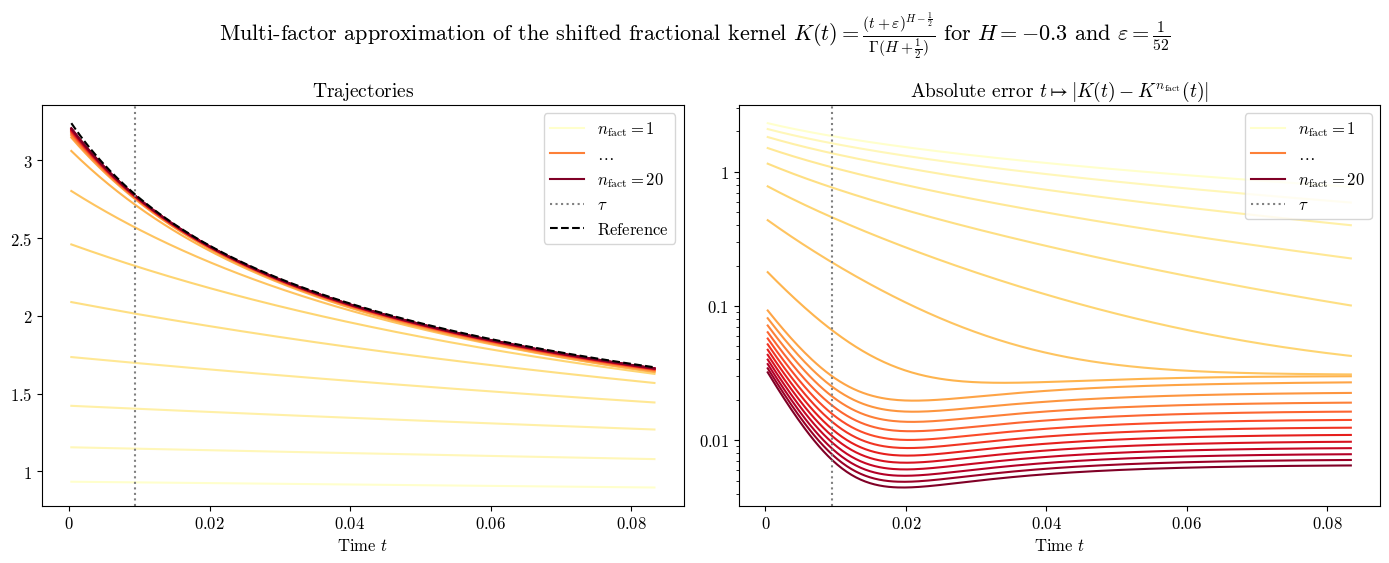

In [256]:
cmap = plt.get_cmap("YlOrRd", len(n_fact_values))
norm = mcolors.Normalize(vmin=n_fact_values.min(), vmax=n_fact_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(1, 2, figsize=(14,5.7))
for i, n_fact in enumerate(n_fact_values) : 
    color = cmap(norm(n_fact))
    if i == 0 or i == len(n_fact_values)-1 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
    elif i == len(n_fact_values)//2 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$\ldots$")
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color)
        ax[1].semilogy(t_grid[1:], np.abs(K_shift(t_grid[1:], H, eps) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color)
ax[0].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[1].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[0].plot(t_grid[1:], K_shift(t_grid[1:], H, eps), color="black", linestyle="--", label=r"$\text{Reference}$")

for i in range(2) : 
    ax[i].legend(fontsize=12, loc="upper right")
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\text{Trajectories}$", fontsize=14)
ax[1].set_title(r"$\text{Absolute error }t\mapsto|K(t)-K^{n_\text{fact}}(t)|$", fontsize=14)
fig.suptitle(r"$\text{Multi-factor approximation of the shifted fractional kernel }K(t) = \frac{(t+\varepsilon)^{H-\frac{1}{2}}}{\Gamma(H+\frac{1}{2})} \text{ for } H=-0.3 \text{ and } \varepsilon=\frac{1}{52}$", fontsize=16)
plt.tight_layout()
plt.show()

### I.3. Gamma kernel 

In [3]:
H = 0.05 
n_fact_values = np.arange(1, 31)
nu = 5

In [4]:
w_star_values, x_star_values = [], []
for n_fact in n_fact_values : 
    r_star, w_star, x_star = compute_r_optimal(n_fact, H, tau, T, eps=0.0, nu=nu, r_min=1.0001, r_max=5.0)
    w_star_values.append(w_star); x_star_values.append(x_star)

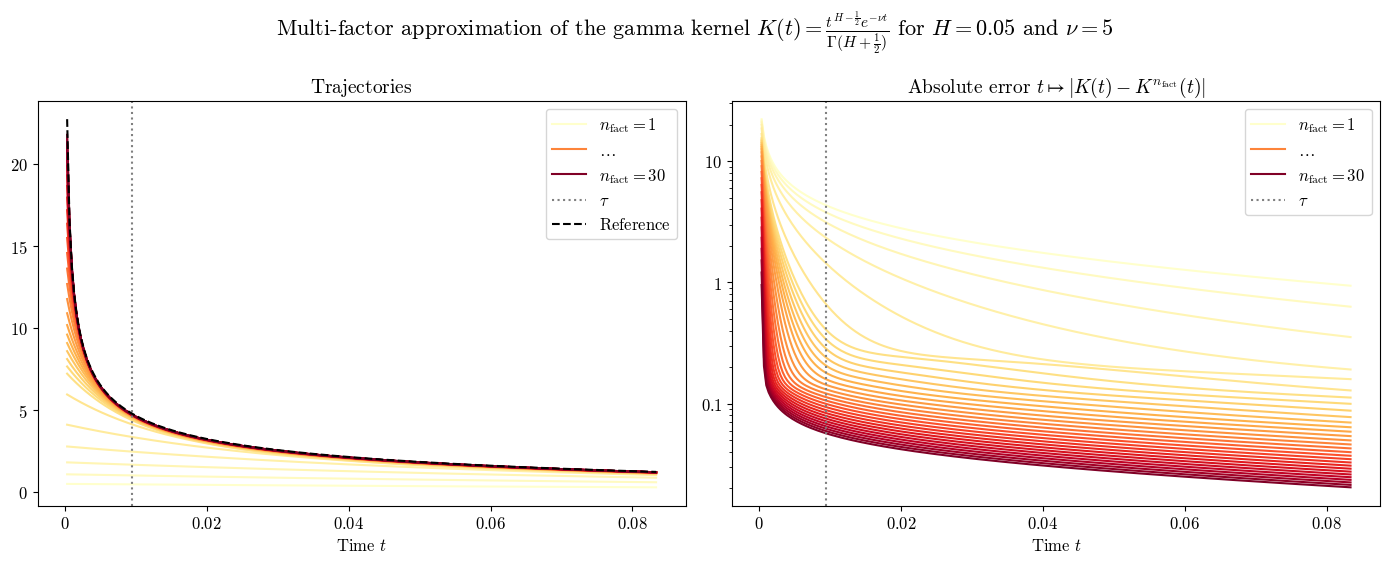

In [5]:
cmap = plt.get_cmap("YlOrRd", len(n_fact_values))
norm = mcolors.Normalize(vmin=n_fact_values.min(), vmax=n_fact_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(1, 2, figsize=(14,5.7))
for i, n_fact in enumerate(n_fact_values) : 
    color = cmap(norm(n_fact))
    if i == 0 or i == len(n_fact_values)-1 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
        ax[1].semilogy(t_grid[1:], np.abs(K_gamma(t_grid[1:], H, nu) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$n_\text{fact}=$"+fr"${n_fact_values[i]}$")
    elif i == len(n_fact_values)//2 : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color, label=r"$\ldots$")
        ax[1].semilogy(t_grid[1:], np.abs(K_gamma(t_grid[1:], H, nu) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid[1:], np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0), color=color)
        ax[1].semilogy(t_grid[1:], np.abs(K_gamma(t_grid[1:], H, nu) - np.sum(w_star_values[i][:, None] * np.exp(-x_star_values[i][:, None] * t_grid[None,1:]), axis=0)), color=color)
ax[0].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[1].axvline(tau, label=r"$\tau$", linestyle=":", color="gray")
ax[0].plot(t_grid[1:], K_gamma(t_grid[1:], H, nu), color="black", linestyle="--", label=r"$\text{Reference}$")

for i in range(2) : 
    ax[i].legend(fontsize=12)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$\text{Trajectories}$", fontsize=14)
ax[1].set_title(r"$\text{Absolute error }t\mapsto|K(t)-K^{n_\text{fact}}(t)|$", fontsize=14)
fig.suptitle(r"$\text{Multi-factor approximation of the gamma kernel }K(t) = \frac{t^{H-\frac{1}{2}}e^{-\nu t}}{\Gamma(H+\frac{1}{2})} \text{ for }$" + fr"$H = {H}$" + r"$\text{ and } $" + fr"$\nu = {nu}$", fontsize=16)
plt.tight_layout()
plt.show()

## II. Trajectories of the Linear Volterra process with $K(t) = \frac{(t+\varepsilon)^{H-\frac12}}{\Gamma(H+\frac12)}$

In [2]:
a1, b1, a2, b2 = 0.25, -1, 0, 1 
y = 0.25 
tau, T = 0, 1/12 
n = 1000 
t_grid = np.linspace(0, T, n+1) 
eps = 1/52
n_fact = 20

In [3]:
N = 10
W, paths = generate_paths(N, n, T)

In [158]:
M_values = np.arange(1, 16) 
H_values = [-0.3, -0.1, 0.1, 0.3]
X_sig_values = []
X_multifactor_values = [] 

for i, H in enumerate(tqdm(H_values)) : 
    r, w, x = compute_r_optimal(n_fact, H, tau, T, eps, r_min=1.0001, r_max=3.0)
    X_sig_values_H = []
    for M in M_values : 
        X_sig = simulate_linear_volterra_signatures(M, y, a1, b1, a2, b2, w, x, paths)
        X_sig_values_H.append(X_sig)
    X_multifactor_euler = simulate_linear_volterra_multifactor_euler(y, a1, b1, a2, b2, w, x, T, W) 
    X_multifactor_values.append(X_multifactor_euler)
    X_sig_values.append(np.array(X_sig_values_H))
X_sig_values = np.array(X_sig_values)
X_multifactor_values = np.array(X_multifactor_values)

100%|█████████████████████████████████████████████| 4/4 [00:39<00:00,  9.92s/it]


In [159]:
X_multifactor_values.shape, X_sig_values.shape

((4, 10, 1001), (4, 15, 10, 1001))

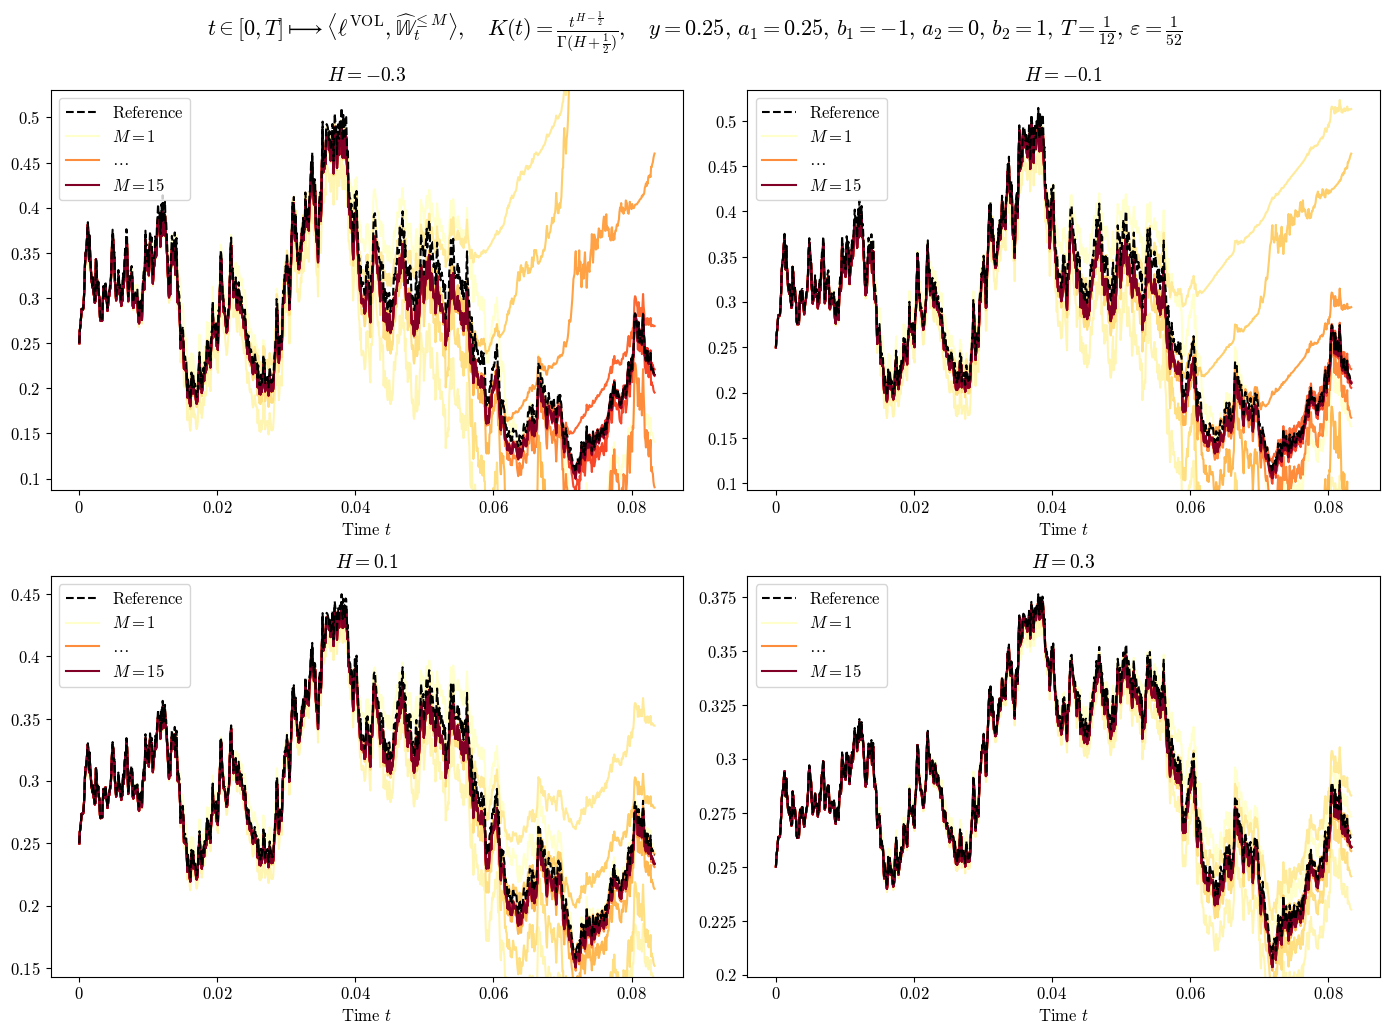

In [192]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

idx = 3

fig, ax = plt.subplots(2, 2, figsize=(14,10.5))
ax = ax.flatten() 

for i, H in enumerate(H_values) :
    ax[i].plot(t_grid, X_multifactor_values[i, idx ,:], color="black", linestyle="--", label=r"$\text{Reference}$", zorder=1)
    ylim = ax[i].get_ylim()
    for j, M in enumerate(M_values) : 
        color = cmap(norm(M))
        if j == 0 or j == len(M_values) - 1 : 
            ax[i].plot(t_grid, X_sig_values[i, j, idx, :], color=color, zorder=0, label=r"$M=$" + fr"${M}$")
        elif j == len(M_values)//2 : 
            ax[i].plot(t_grid, X_sig_values[i, j, idx, :], color=color, zorder=0, label=r"$\ldots$")
        else : 
            ax[i].plot(t_grid, X_sig_values[i, j, idx, :], color=color, zorder=0)
    ax[i].set_ylim(ylim)
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 
    ax[i].set_title(r"$H=$"+fr"${H}$", fontsize=14)
fig.suptitle(r"$t\in[0,T]\longmapsto \left\langle \ell^\text{VOL}, \widehat{\mathbb{W}}_t^{\leq M} \right \rangle, \quad K(t)= \frac{t^{H-\frac{1}{2}}}{\Gamma(H+\frac{1}{2})}, \quad y=0.25,\, a_1 =0.25,\,b_1=-1,\, a_2=0,\, b_2=1,\, T = \frac{1}{12},\, \varepsilon=\frac{1}{52}$", fontsize=16)
plt.tight_layout()
plt.show()

## III. Moments 

### III.1. Fawcett's formula 

In [144]:
M, T, n, N = 2, 1/12, 252, 5000
W, paths = generate_paths(N, n, T)
W_sig = iisignature.sig(paths, M, 2) 
t_grid = np.linspace(0, T, n+1) 

In [145]:
fawcett = np.array([expected_signature_bm(t, M)[1:] for t in t_grid[1:]])

In [146]:
mean, _ , lower, upper = monte_carlo(W_sig, mode="axis0")

In [147]:
np.abs(fawcett - mean).max()

np.float64(0.0046087627582728245)

### III.2. Moments of a Linear Volterra process 

In [2]:
y, a1, b1, a2, b2, H = 0.25, 0.25, -1, 0, 1, 0.1
tau, T = 1/106, 1/26
n = 500 
t_grid = np.linspace(0, T, n+1) 
eps = 1/52
n_fact = 10

In [3]:
r, w, x = compute_r_optimal(n_fact, H, tau, T, eps, r_min=1.0001, r_max=3.0)

In [4]:
N = 50000
W, paths = generate_paths(N, n, T)

In [5]:
X = simulate_linear_volterra_multifactor_euler(y, a1, b1, a2, b2, w, x, T, W) 

In [6]:
E_X_3, _, E_X_3_lower, E_X_3_upper = monte_carlo(X**3, mode="axis0")
E_X_4, _, E_X_4_lower, E_X_4_upper = monte_carlo(X**4, mode="axis0")

In [ ]:
M_values = np.arange(1, 13)
l_shupow_3, l_shupow_4 = [], []
for M in tqdm(M_values) : 
    l = compute_l_linear_volterra_multifactor(y, a1, b1, a2, b2, w, x, M) 
    l_dict = vector_to_dict_full(l, 2, M) 
    l_shupow_dict = shuffle_power(l_dict, 3, M)
    l_shupow_3.append(dict_to_vector_full(l_shupow_dict, 2, M))
    l_shupow_dict = shuffle_power(l_dict, 4, M)
    l_shupow_4.append(dict_to_vector_full(l_shupow_dict, 2, M))

In [8]:
E_X_3_sig, E_X_4_sig = [], []
for i, M in enumerate(M_values) : 
    E_X_3_sig.append(unconditionals_moments(M, 3, l_shupow_3[i], T, n))
    E_X_4_sig.append(unconditionals_moments(M, 4, l_shupow_4[i], T, n))
E_X_3_sig = np.array(E_X_3_sig)
E_X_4_sig = np.array(E_X_4_sig)

In [9]:
E_X_3_sig_cond, E_X_4_sig_cond = [], [] 
for i, M in enumerate(tqdm(M_values)) : 
    E_X_3_sig_cond.append(conditionals_moments(M, 3, l_shupow_3[i], T, paths[:20]))
    E_X_4_sig_cond.append(conditionals_moments(M, 4, l_shupow_4[i], T, paths[:20]))
E_X_3_sig_cond = np.array(E_X_3_sig_cond)
E_X_4_sig_cond = np.array(E_X_4_sig_cond)

100%|███████████████████████████████████████████| 12/12 [00:30<00:00,  2.53s/it]


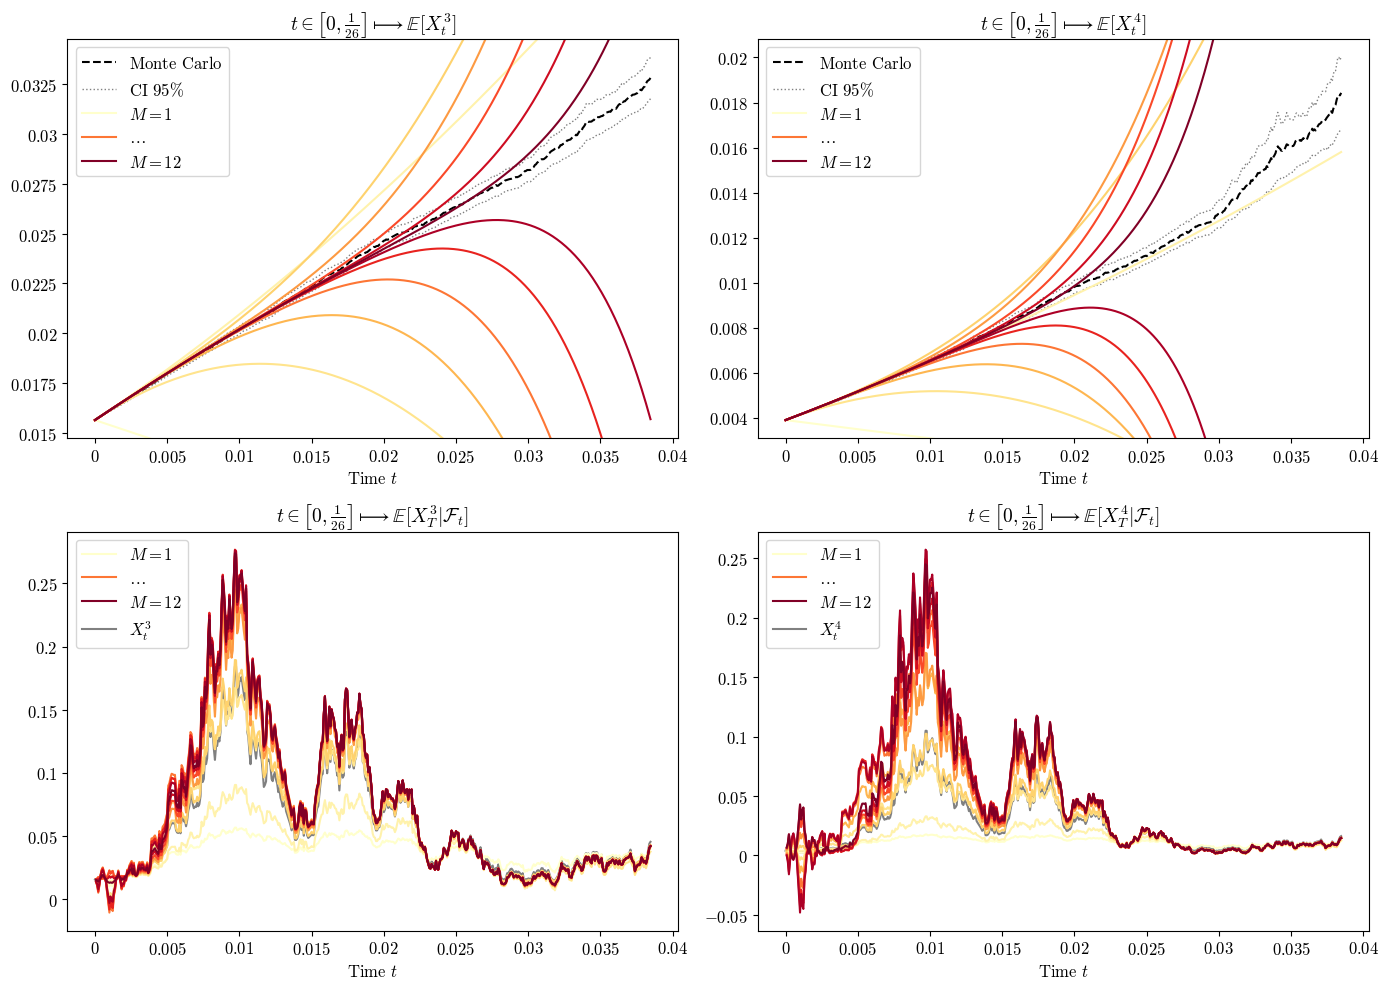

In [32]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14,10))
ax = ax.flatten() 
ax[0].plot(t_grid, E_X_3, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[0].plot(t_grid, E_X_3_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[0].plot(t_grid, E_X_3_upper, color="gray", linestyle=":", lw=1)
lims = ax[0].set_ylim()

for i, M in enumerate(M_values) :
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2  : 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color)

ax[0].set_ylim(lims)

ax[1].plot(t_grid, E_X_4, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[1].plot(t_grid, E_X_4_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[1].plot(t_grid, E_X_4_upper, color="gray", linestyle=":", lw=1)
lims = ax[1].set_ylim()

for i, M in enumerate(M_values) :
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[1].plot(t_grid, E_X_4_sig[i], color=color, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2  : 
        ax[1].plot(t_grid, E_X_4_sig[i], color=color, label=r"$\ldots$")
    else :
        ax[1].plot(t_grid, E_X_4_sig[i], color=color)

ax[1].set_ylim(lims)

idx = 3

for i, M in enumerate(M_values) : 
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$\ldots$")
    else : 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1)

ax[2].plot(t_grid, X[idx]**3, zorder=0, color="gray", label=r"$X_t^3$")


for i, M in enumerate(M_values) : 
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$\ldots$")
    else : 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1)

ax[3].plot(t_grid, X[idx]**4, zorder=0, color="gray", label=r"$X_t^4$")

for i in range(4) : 
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$t \in \left[0, \frac{1}{26}\right] \longmapsto \mathbb{E}[X_t^3]$", fontsize=14)
ax[1].set_title(r"$t \in \left[0, \frac{1}{26}\right] \longmapsto \mathbb{E}[X_t^4]$", fontsize=14)
ax[2].set_title(r"$t \in \left[0, \frac{1}{26}\right] \longmapsto \mathbb{E}[X_T^3|\mathcal{F}_t]$", fontsize=14)
ax[3].set_title(r"$t \in \left[0, \frac{1}{26}\right] \longmapsto \mathbb{E}[X_T^4|\mathcal{F}_t]$", fontsize=14)

plt.tight_layout()
plt.show()

### III.3. Moments of a DE process

In [7]:
a1, b1, c1, lambda1, a2, b2, c2, lambda2, u = 2, 2, -2, 4, 1, 1, -1, -4, 0.25
a1, b1, c1, lambda1, a2, b2, c2, lambda2, u = 0.125, -0.5, -0.5, 1, 0, 0.5, 0.5, -1, 0.25
T = 1
N = 50000
n = 500 
t_grid = np.linspace(0, T, n+1) 
W, paths = generate_paths(N, n, T)

In [8]:
X = simulate_DE_euler(T, u, a1, b1, c1, lambda1, a2, b2, c2, lambda2, W)

In [9]:
E_X_3, _, E_X_3_lower, E_X_3_upper = monte_carlo(X**3, mode="axis0")
E_X_4, _, E_X_4_lower, E_X_4_upper = monte_carlo(X**4, mode="axis0")

In [24]:
M_values = np.arange(1, 13)
l_shupow_3, l_shupow_4 = [], []
for M in tqdm(M_values) : 
    l_partial = compute_l_DE(u, a1, b1, c1, lambda1, a2, b2, c2, lambda2, M)
    l = np.concatenate([[u], l_partial])
    l_dict = vector_to_dict_full(l, 2, M) 
    l_shupow_dict = shuffle_power(l_dict, 3, M)
    l_shupow_3.append(dict_to_vector_full(l_shupow_dict, 2, M))
    l_shupow_dict = shuffle_power(l_dict, 4, M)
    l_shupow_4.append(dict_to_vector_full(l_shupow_dict, 2, M))

100%|███████████████████████████████████████████| 12/12 [02:25<00:00, 12.15s/it]


In [25]:
E_X_3_sig, E_X_4_sig = [], []
for i, M in enumerate(M_values) : 
    E_X_3_sig.append(unconditionals_moments(M, 3, l_shupow_3[i], T, n))
    E_X_4_sig.append(unconditionals_moments(M, 4, l_shupow_4[i], T, n))
E_X_3_sig = np.array(E_X_3_sig)
E_X_4_sig = np.array(E_X_4_sig)

In [26]:
E_X_3_sig_cond, E_X_4_sig_cond = [], [] 
for i, M in enumerate(tqdm(M_values)) : 
    E_X_3_sig_cond.append(conditionals_moments(M, 3, l_shupow_3[i], T, paths[:20]))
    E_X_4_sig_cond.append(conditionals_moments(M, 4, l_shupow_4[i], T, paths[:20]))
E_X_3_sig_cond = np.array(E_X_3_sig_cond)
E_X_4_sig_cond = np.array(E_X_4_sig_cond)

100%|███████████████████████████████████████████| 12/12 [00:30<00:00,  2.50s/it]


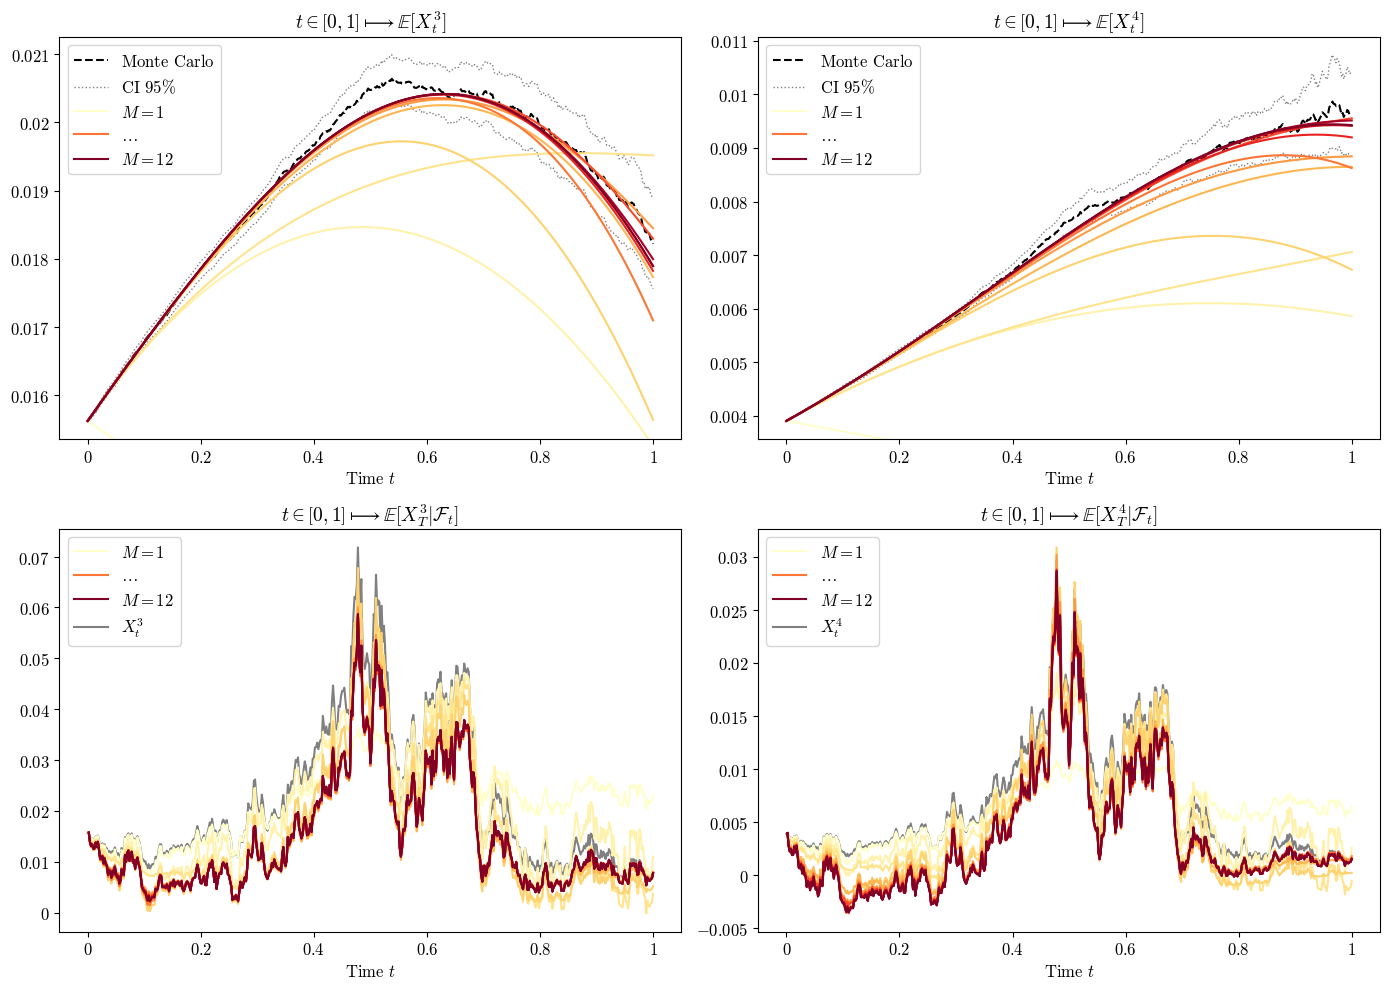

In [30]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(2, 2, figsize=(14,10))
ax = ax.flatten() 
ax[0].plot(t_grid, E_X_3, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[0].plot(t_grid, E_X_3_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[0].plot(t_grid, E_X_3_upper, color="gray", linestyle=":", lw=1)
lims = ax[0].set_ylim()

for i, M in enumerate(M_values) :
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2  : 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(t_grid, E_X_3_sig[i], color=color)

ax[0].set_ylim(lims)

ax[1].plot(t_grid, E_X_4, color="black", linestyle="--", label=r"$\text{Monte Carlo}$")
ax[1].plot(t_grid, E_X_4_lower, color="gray", linestyle=":", lw=1, label=r"$\text{CI }95\%$")
ax[1].plot(t_grid, E_X_4_upper, color="gray", linestyle=":", lw=1)
lims = ax[1].set_ylim()

for i, M in enumerate(M_values) :
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[1].plot(t_grid, E_X_4_sig[i], color=color, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2  : 
        ax[1].plot(t_grid, E_X_4_sig[i], color=color, label=r"$\ldots$")
    else :
        ax[1].plot(t_grid, E_X_4_sig[i], color=color)

ax[1].set_ylim(lims)

idx = 0

for i, M in enumerate(M_values) : 
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$\ldots$")
    else : 
        ax[2].plot(t_grid[1:], E_X_3_sig_cond[i, idx, 1:], color=color, zorder=1)

ax[2].plot(t_grid, X[idx]**3, zorder=0, color="gray", label=r"$X_t^3$")


for i, M in enumerate(M_values) : 
    color = cmap(norm(M)) 
    if i == 0 or i == len(M_values) - 1: 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$M=$"+fr"${M}$")
    elif i == len(M_values)//2 : 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1, label=r"$\ldots$")
    else : 
        ax[3].plot(t_grid[1:], E_X_4_sig_cond[i, idx, 1:], color=color, zorder=1)

ax[3].plot(t_grid, X[idx]**4, zorder=0, color="gray", label=r"$X_t^4$")

for i in range(4) : 
    ax[i].set_xlabel(r"$\text{Time }t$", fontsize=12)
    ax[i].legend(loc="upper left", fontsize=12)
    ax[i].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(axis='both', labelsize=12) 

ax[0].set_title(r"$t \in \left[0, 1\right] \longmapsto \mathbb{E}[X_t^3]$", fontsize=14)
ax[1].set_title(r"$t \in \left[0, 1\right] \longmapsto \mathbb{E}[X_t^4]$", fontsize=14)
ax[2].set_title(r"$t \in \left[0, 1\right] \longmapsto \mathbb{E}[X_T^3|\mathcal{F}_t]$", fontsize=14)
ax[3].set_title(r"$t \in \left[0, 1\right] \longmapsto \mathbb{E}[X_T^4|\mathcal{F}_t]$", fontsize=14)

plt.tight_layout()
plt.show()